# Keras Classification Project


<div style="text-align: center;">
  <a href="https://colab.research.google.com/github/MinooSdpr/Machine-Learning-101/blob/main/Session%2017/17_2%20-%20Keras%20Classification.ipynb">
    <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab" />
  </a>
  &nbsp;
  <a href="https://github.com/MinooSdpr/Machine-Learning-101/blob/main/Session%2017/17_2%20-%20Keras%20Classification.ipynb">
    <img src="https://img.shields.io/badge/Open%20in-GitHub-24292e?logo=github&logoColor=white" alt="Open In GitHub" />
  </a>
</div>

In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv('diabetes_prediction_dataset.csv')
df.head()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  object 
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  object 
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 6.9+ MB


In [3]:
df.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
age,100000.0,41.885856,22.516840,0.08,24.00,43.00,60.00,80.00
hypertension,100000.0,0.074850,0.263150,0.00,0.00,0.00,0.00,1.00
heart_disease,100000.0,0.039420,0.194593,0.00,0.00,0.00,0.00,1.00
bmi,100000.0,27.320767,6.636783,10.01,23.63,27.32,29.58,95.69
HbA1c_level,100000.0,5.527507,1.070672,3.50,4.80,5.80,6.20,9.00
blood_glucose_level,100000.0,138.058060,40.708136,80.00,100.00,140.00,159.00,300.00
diabetes,100000.0,0.085000,0.278883,0.00,0.00,0.00,0.00,1.00


In [4]:
df.isnull().sum()

gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
HbA1c_level            0
blood_glucose_level    0
diabetes               0
dtype: int64

## EDA

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

Text(0.5, 1.0, 'Diabetes Class Distribution')

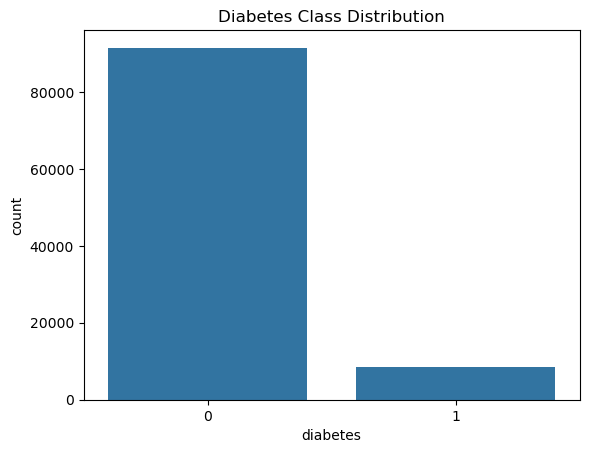

In [6]:
sns.countplot(x='diabetes', data=df)
plt.title('Diabetes Class Distribution')

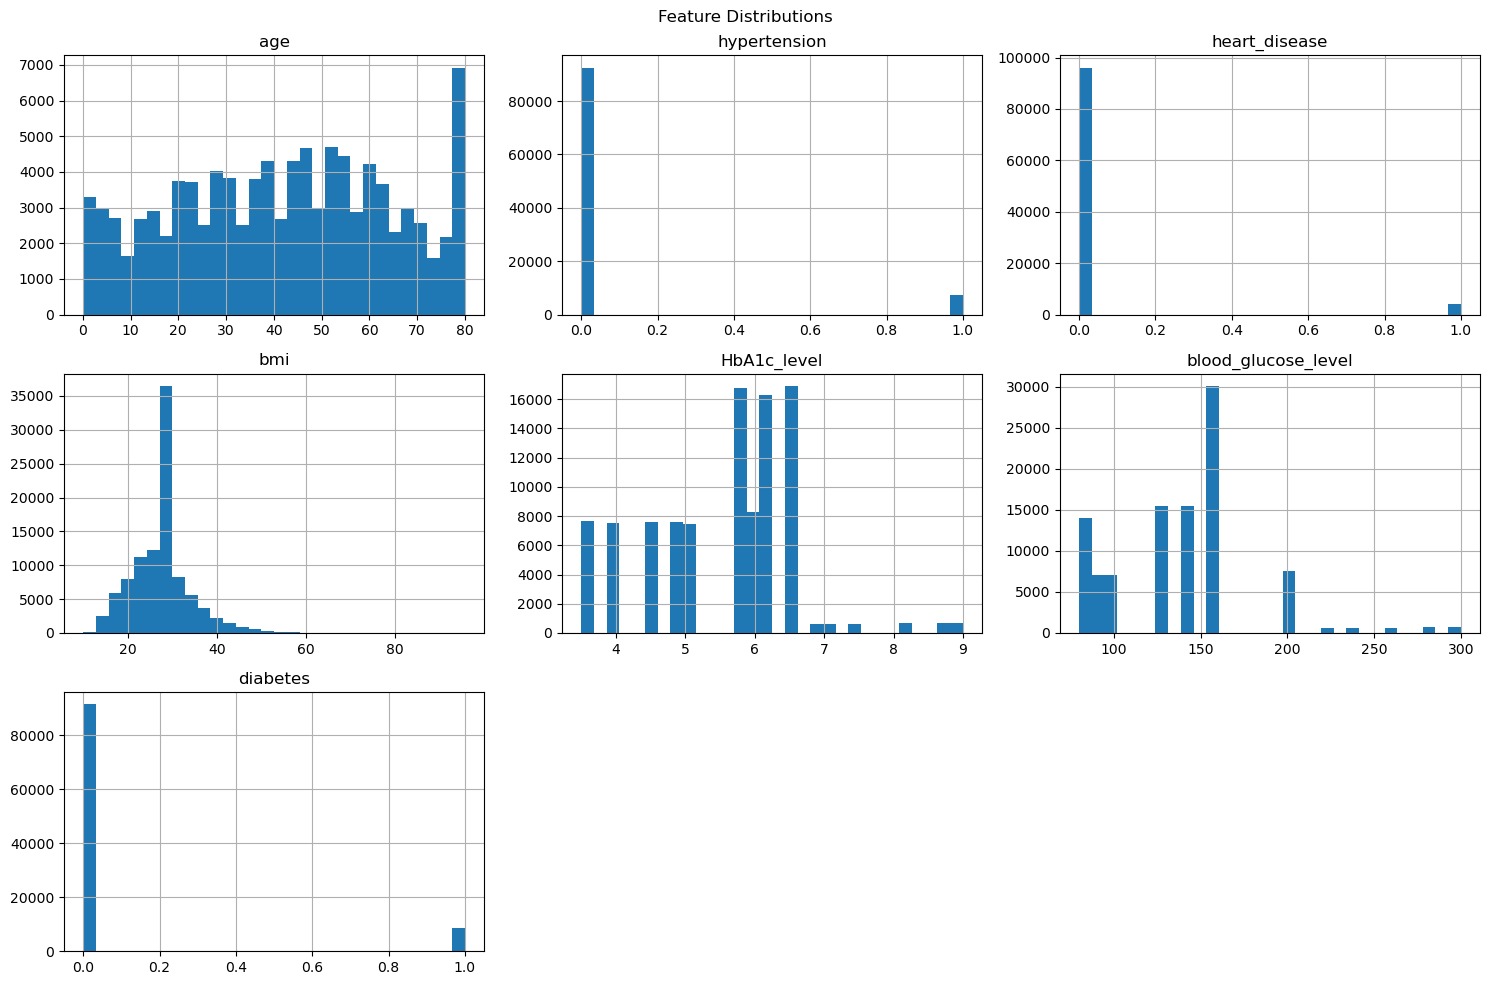

In [7]:
df.hist(bins=30, figsize=(15, 10))
plt.suptitle('Feature Distributions')
plt.tight_layout()

In [8]:
categorical_cols = df.select_dtypes(include=['object']).columns
print("Categorical columns:", categorical_cols.tolist())

Categorical columns: ['gender', 'smoking_history']


In [9]:
from sklearn.preprocessing import LabelEncoder

df_encoded = df.copy()
label_encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col])
    label_encoders[col] = le

df_encoded.head()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,0,80.0,0,1,4,25.19,6.6,140,0
1,0,54.0,0,0,0,27.32,6.6,80,0
2,1,28.0,0,0,4,27.32,5.7,158,0
3,0,36.0,0,0,1,23.45,5.0,155,0
4,1,76.0,1,1,1,20.14,4.8,155,0


<Axes: >

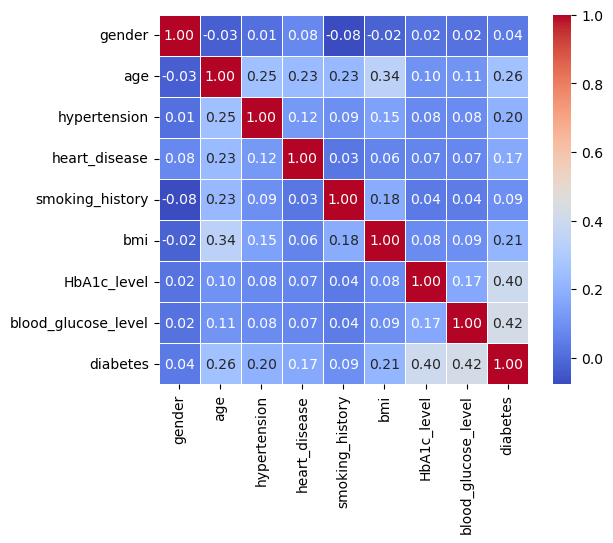

In [10]:
sns.heatmap(df_encoded.corr(), annot=True, fmt=".2f", cmap='coolwarm', square=True, linewidths=0.5)

## Train Test Split

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df_encoded.drop('diabetes', axis=1)
y = df_encoded['diabetes']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Creating the Model

    # For a binary classification problem
    model.compile(optimizer='rmsprop',
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
                  
    

In [12]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Activation,Dropout, Input

In [13]:
X_train.shape

(80000, 8)

In [14]:
input_dim = X_train_scaled.shape[1]

model = Sequential([
    Input(shape=(input_dim,)),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='rmsprop',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 64)                  │             576 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,689 (10.50 KB)

 Trainable params: 2,689 (10.50 KB)

 Non-trainable params: 0 (0.00 B)

## Training the Model 

### Example One: Choosing too many epochs and overfitting!

In [15]:
history = model.fit(
    X_train_scaled, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

Epoch 1/50
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9471 - loss: 0.1509 - val_accuracy: 0.9603 - val_loss: 0.1125
Epoch 2/50
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9590 - loss: 0.1203 - val_accuracy: 0.9613 - val_loss: 0.1098
Epoch 3/50
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9619 - loss: 0.1133 - val_accuracy: 0.9630 - val_loss: 0.1075
Epoch 4/50
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9638 - loss: 0.1082 - val_accuracy: 0.9636 - val_loss: 0.1041
Epoch 5/50
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9658 - loss: 0.1024 - val_accuracy: 0.9658 - val_loss: 0.0977
Epoch 6/50
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9665 - loss: 0.1006 - val_accuracy: 0.9669 - val_loss: 0.0948
Epoch 7/50
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9672 - loss: 0.0998 - val_accuracy: 0.9675 - val_loss: 0.0941
Epoch 8/50
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9677 - loss: 0.0980 - 

Epoch 485/600
14/14 [==============================] - 0s 10ms/step - loss: 0.0279 - val_loss: 0.7472
Epoch 486/600
14/14 [==============================] - 0s 11ms/step - loss: 0.0232 - val_loss: 0.7099
Epoch 487/600
14/14 [==============================] - 0s 13ms/step - loss: 0.0224 - val_loss: 0.7357
Epoch 488/600
14/14 [==============================] - 0s 11ms/step - loss: 0.0223 - val_loss: 0.7125
Epoch 489/600
14/14 [==============================] - 0s 12ms/step - loss: 0.0267 - val_loss: 0.7215
Epoch 490/600
14/14 [==============================] - 0s 7ms/step - loss: 0.0264 - val_loss: 0.7144
Epoch 491/600
14/14 [==============================] - 0s 11ms/step - loss: 0.0224 - val_loss: 0.7110
Epoch 492/600
14/14 [==============================] - 0s 11ms/step - loss: 0.0231 - val_loss: 0.7068
Epoch 493/600
14/14 [==============================] - 0s 9ms/step - loss: 0.0241 - val_loss: 0.7464
Epoch 494/600
14/14 [==============================] - 0s 11ms/step - loss: 0.0312 -

14/14 [==============================] - 0s 10ms/step - loss: 0.0162 - val_loss: 0.7892
Epoch 566/600
14/14 [==============================] - 0s 10ms/step - loss: 0.0160 - val_loss: 0.7868
Epoch 567/600
14/14 [==============================] - 0s 10ms/step - loss: 0.0161 - val_loss: 0.7871
Epoch 568/600
14/14 [==============================] - 0s 12ms/step - loss: 0.0150 - val_loss: 0.7914
Epoch 569/600
14/14 [==============================] - 0s 8ms/step - loss: 0.0135 - val_loss: 0.7911
Epoch 570/600
14/14 [==============================] - 0s 9ms/step - loss: 0.0151 - val_loss: 0.7925
Epoch 571/600
14/14 [==============================] - 0s 9ms/step - loss: 0.0143 - val_loss: 0.7856
Epoch 572/600
14/14 [==============================] - 0s 10ms/step - loss: 0.0141 - val_loss: 0.7849
Epoch 573/600
14/14 [==============================] - 0s 11ms/step - loss: 0.0136 - val_loss: 0.7913
Epoch 574/600
14/14 [==============================] - 0s 8ms/step - loss: 0.0136 - val_loss: 0.803

In [16]:
model_loss = pd.DataFrame(model.history.history)

In [17]:
model_loss[:20]

,accuracy,loss,val_accuracy,val_loss
0,0.947141,0.150851,0.960312,0.112505
1,0.958984,0.120284,0.961312,0.109799
2,0.961906,0.113256,0.963000,0.107483
3,0.963766,0.108203,0.963562,0.104057
4,0.965813,0.102413,0.965813,0.097728
5,0.966469,0.100611,0.966937,0.094847
6,0.967188,0.099777,0.967500,0.094097
7,0.967672,0.098049,0.967500,0.092073
8,0.967781,0.097384,0.966438,0.094764
9,0.967906,0.097367,0.967375,0.092912


<Axes: >

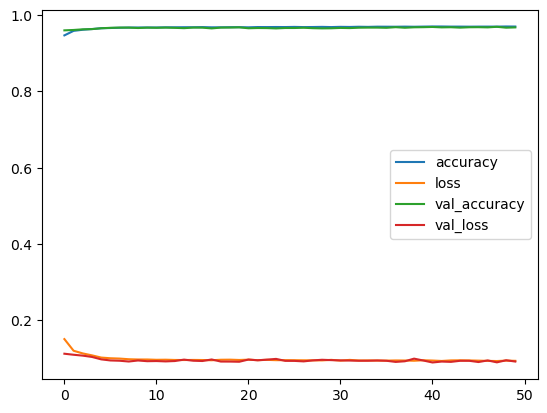

In [18]:
model_loss.plot()

# Model Evaluation

In [19]:
predict_x = model.predict(X_test)
predict_x

625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 596us/step


array([[1.],
       [1.],
       [1.],
       ...,
       [1.],
       [1.],
       [1.]], dtype=float32)

In [20]:
predict_x.min()

1.0

In [21]:
predict_x.max()

1.0

In [22]:
predict_x.mean()

1.0

In [23]:
predict_x.shape

(20000, 1)

In [24]:
from sklearn.metrics import classification_report,confusion_matrix
print(confusion_matrix(y_test,predict_x))

[[    0 18300]
 [    0  1700]]


In [25]:
print(classification_report(y_test,predict_x))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00     18300
           1       0.09      1.00      0.16      1700

    accuracy                           0.09     20000
   macro avg       0.04      0.50      0.08     20000
weighted avg       0.01      0.09      0.01     20000



C:\Users\PC-GAM\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\PC-GAM\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\PC-GAM\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## Data Balancing with SMOTE (Synthetic Minority Over-sampling Technique)

One of the biggest challenges in classification tasks is dealing with **imbalanced datasets**, where one class significantly outnumbers the other(s). For example, in medical diagnosis datasets like diabetes prediction, the number of non-diabetic patients (class 0) is often much higher than diabetic patients (class 1).

Training a model on such imbalanced data can lead to **biased predictions**, where the model favors the majority class and fails to learn meaningful patterns about the minority class.

### What is SMOTE?

**SMOTE (Synthetic Minority Over-sampling Technique)** is an advanced over-sampling method that addresses class imbalance by **generating synthetic samples** of the minority class, rather than simply duplicating existing ones.

Developed by Chawla et al. in 2002, SMOTE helps the model learn a more general decision boundary and prevents overfitting caused by random oversampling.

---

### How SMOTE Works

1. **Select a Minority Class Sample**: For each instance in the minority class, SMOTE finds its *k* nearest neighbors (typically `k=5`).

2. **Randomly Select Neighbors**: One or more of the *k* neighbors are randomly selected.

3. **Generate Synthetic Samples**: For each selected neighbor, a synthetic sample is created by **interpolating** between the original sample and its neighbor:
   $$
   \text{synthetic\_point} = x_i + \lambda \cdot (x_{\text{neighbor}} - x_i)
   $$
   where $\lambda \in [0,1]$ is a random number.

4. **Repeat**: This process is repeated until the minority class is balanced with the majority class.

---

### Advantages of SMOTE

- ✅ Reduces bias toward the majority class
- ✅ Improves model performance on the minority class
- ✅ Helps the model learn a better decision boundary
- ✅ Avoids overfitting from naive oversampling (e.g., just duplicating rows)

---

### When to Use SMOTE

- Binary or multi-class classification problems with **class imbalance**
- When you want to improve **recall**, **F1-score**, or **AUC** for the minority class
- Especially helpful in **medical**, **fraud detection**, and **anomaly detection** tasks

---

### Considerations & Limitations

- ❗ Can generate **noisy** or **less meaningful** synthetic samples if the data has many outliers
- ❗ Works only with **numerical features** — categorical features must be encoded before applying SMOTE
- ❗ SMOTE should only be applied to the **training set**, not the test set (to avoid data leakage)

In [27]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train_scaled, y_train)

from collections import Counter
print("After SMOTE:", Counter(y_train_bal))

After SMOTE: Counter({1: 73200, 0: 73200})


In [28]:
from tensorflow.keras import Sequential, Input
from tensorflow.keras.layers import Dense, Dropout

model_bal = Sequential([
    Input(shape=(X_train_bal.shape[1],)),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

model_bal.compile(optimizer='rmsprop',
                  loss='binary_crossentropy',
                  metrics=['accuracy'])

history_bal = model_bal.fit(
    X_train_bal, y_train_bal,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

Epoch 1/50
3660/3660 ━━━━━━━━━━━━━━━━━━━━ 6s 1ms/step - accuracy: 0.8868 - loss: 0.2426 - val_accuracy: 0.8640 - val_loss: 0.2681
Epoch 2/50
3660/3660 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - accuracy: 0.9035 - loss: 0.2019 - val_accuracy: 0.8463 - val_loss: 0.2760
Epoch 3/50
3660/3660 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - accuracy: 0.9080 - loss: 0.1930 - val_accuracy: 0.8607 - val_loss: 0.2688
Epoch 4/50
3660/3660 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - accuracy: 0.9109 - loss: 0.1896 - val_accuracy: 0.8520 - val_loss: 0.2700
Epoch 5/50
3660/3660 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - accuracy: 0.9115 - loss: 0.1882 - val_accuracy: 0.8684 - val_loss: 0.2600
Epoch 6/50
3660/3660 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - accuracy: 0.9116 - loss: 0.1876 - val_accuracy: 0.8503 - val_loss: 0.2874
Epoch 7/50
3660/3660 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - accuracy: 0.9123 - loss: 0.1875 - val_accuracy: 0.8503 - val_loss: 0.2765
Epoch 8/50
3660/3660 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - accuracy: 0.9122 - loss: 0.1863 - 

In [29]:
y_pred_bal = (model_bal.predict(X_test_scaled) > 0.5).astype("int32")

print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_bal))


625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 684us/step
Confusion Matrix:
 [[17274  1026]
 [  250  1450]]


In [30]:
print("\nClassification Report:\n", classification_report(y_test, y_pred_bal))


Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.94      0.96     18300
           1       0.59      0.85      0.69      1700

    accuracy                           0.94     20000
   macro avg       0.79      0.90      0.83     20000
weighted avg       0.95      0.94      0.94     20000



<div style="float:right;">
  <a href="https://github.com/MinooSdpr/Machine-Learning-101/blob/main/Session%2006/Session%2006%20-%20Matplotlib%20Concepts_1.ipynb"
     style="
       display:inline-block;
       padding:8px 20px;
       background-color:#414f6f;
       color:white;
       border-radius:12px;
       text-decoration:none;
       font-family:sans-serif;
       transition:background-color 0.3s ease;
     ">
    ▶️ Next
  </a>
</div>